In [1]:
!pip install keras
!pip install tensorflow
!pip install pandas

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

In [3]:
csv_folder_path = "C:/Users/saket/Downloads/osfstorage-labels"
csv_files = [os.path.join(csv_folder_path, file) for file in os.listdir(csv_folder_path) if file.endswith('.csv')]
data_frames = [pd.read_csv(file) for file in csv_files]
combined_data = pd.concat(data_frames, ignore_index=True)
combined_data = combined_data.dropna()
combined_data.to_csv("C:/Users/saket/Downloads/combined_labels.csv", index=False)
print("Combined CSV Data:")
print(combined_data)

Combined CSV Data:
       Unnamed: 0                                    filename  LE_left  \
0               0  001/0/2022-09-26 08:07:22.792702-37704.jpg      131   
1               1  001/0/2022-09-26 08:07:23.101953-37752.jpg      163   
2               2  001/0/2022-09-26 08:07:22.818864-37708.jpg      130   
3               3  001/0/2022-09-26 08:07:23.225207-37772.jpg      183   
4               4  001/0/2022-09-26 08:07:23.126469-37756.jpg      167   
...           ...                                         ...      ...   
11204          45  221/0/2022-11-14 13:11:06.715420-38758.jpg      238   
11205          46  221/0/2022-11-14 13:09:06.141864-19503.jpg      209   
11206          47    221/0/2022-11-14 13:07:07.796276-644.jpg      153   
11207          48   221/0/2022-11-14 13:07:55.343058-8243.jpg      187   
11208          49  221/0/2022-11-14 13:08:07.137949-10115.jpg      189   

       LE_top  LE_right  LE_bottom  RE_left  RE_top  RE_right  RE_bottom   lx  \
0         4

In [4]:
file_path = "C:/Users/saket/Downloads/combined_labels.csv"
try:
    df = pd.read_csv(file_path)
    df_filtered = df[~((df['lx'] == df['rx']) & (df['ly'] == df['ry']))]
    output_path = "C:/Users/saket/Downloads/combined_labels_filtered.csv"
    df_filtered.to_csv(output_path, index=False)
    print(f"Filtered CSV has been saved to: {output_path}")
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the file path and try again.")


Filtered CSV has been saved to: C:/Users/saket/Downloads/combined_labels_filtered.csv


In [5]:
image_base_path = "C:/Users/saket/Downloads/osfstorage-imgs"
def list_image_files(image_dir):
    image_files = []
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, file))
    return image_files
image_files = list_image_files(image_base_path)
image_data = []
for image_path in image_files:
    filename = os.path.basename(image_path)
    img = load_img(image_path, target_size=(299, 299), color_mode='rgb')
    img_array = img_to_array(img)
    image_data.append({'filename': filename, 'image_array': img_array})
image_df = pd.DataFrame(image_data)
image_df.to_pickle("C:/Users/saket/Downloads/image_data.pkl")
print("Image Data DataFrame:")
print(image_df.head())

Image Data DataFrame:
                             filename  \
0    2022-09-26 08_03_05.243889-0.jpg   
1  2022-09-26 08_03_06.004434-108.jpg   
2  2022-09-26 08_03_07.743760-364.jpg   
3  2022-09-26 08_03_08.755670-514.jpg   
4  2022-09-26 08_03_10.555323-775.jpg   

                                         image_array  
0  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...  
1  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...  
2  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...  
3  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...  
4  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...  


In [6]:
csv_file_path = "C:/Users/saket/Downloads/combined_labels_filtered.csv"
image_base_path = "C:/Users/saket/OneDrive/Desktop/project/osfstorage-imgs"

In [7]:
data = pd.read_csv(csv_file_path)
data = data.dropna()
data_sampled = data.sample(n=700, random_state=0)
filenames = data_sampled['filename'].values
features = ['lx', 'ly', 'rx', 'ry']
def find_image_file(csv_filename, image_dir):
    parts = csv_filename.split('/')
    timestamp_id = parts[-1].split('-')[0] 
    corrected_timestamp_id = timestamp_id.replace(':', '/')
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if corrected_timestamp_id in file:
                return os.path.join(root, file)
    return None
def load_images(filenames, base_path):
    images = []
    for filename in filenames:
        img_path = find_image_file(filename, base_path)
        if img_path and os.path.exists(img_path):
            img = load_img(img_path, target_size=(960,960), color_mode='rgb')  
            img_array = img_to_array(img)
            images.append(img_array)
        else:
            print(f"File not found for CSV entry: {filename}")
            images.append(np.zeros((960,960, 3)))  
    return np.array(images)
image_width, image_height = 960,960
data_sampled['lx'] = data_sampled['lx'] / image_width
data_sampled['ly'] = data_sampled['ly'] / image_height
data_sampled['rx'] = data_sampled['rx'] / image_width
data_sampled['ry'] = data_sampled['ry'] / image_height
X_images = load_images(filenames, image_base_path)
y = data_sampled[features].values
X_train, X_temp, y_train, y_temp = train_test_split(X_images, y, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)


In [8]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(960,960, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='linear')(x) 
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=False,
    fill_mode='nearest'
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)


In [9]:
for layer in base_model.layers:
    layer.trainable = False
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_frozen = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20, 
    callbacks=[early_stopping, reduce_lr]  
)

Epoch 1/20


C:\Users\saket\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 450s 24s/step - loss: 10.8928 - mae: 1.6371 - val_loss: 15.6449 - val_mae: 3.0880 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 452s 25s/step - loss: 7.9299 - mae: 1.4185 - val_loss: 4.8582 - val_mae: 1.0492 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 443s 24s/step - loss: 6.1316 - mae: 1.2393 - val_loss: 3.5154 - val_mae: 0.6150 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 428s 23s/step - loss: 5.2524 - mae: 1.1053 - val_loss: 5.3271 - val_mae: 1.2352 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 427s 24s/step - loss: 4.7718 - mae: 1.0513 - val_loss: 3.1295 - val_mae: 0.5979 - learning_rate: 0.0010
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 465s 27s/step - loss: 4.2630 - mae: 0.9620 - val_loss: 3.1445 - val_mae: 0.6953 - learning_rate: 0.0010
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 430s 24s/step - loss: 3.8924 - mae: 0.8853 - val_loss: 2.9791 - val_mae: 0.6208 - learning_rate: 0.0010
Epoch 8/20
16/1

In [10]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=Adam(learning_rate=0.00001), loss='mse', metrics=['mae'])
history_finetune = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),  
    validation_data=(X_val, y_val),
    epochs=20,  
    callbacks=[reduce_lr]
)


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 435s 13s/step - loss: 2.1296 - mae: 0.4757 - val_loss: 1.8735 - val_mae: 0.3158 - learning_rate: 1.0000e-05
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 417s 13s/step - loss: 2.1268 - mae: 0.4657 - val_loss: 1.8633 - val_mae: 0.3026 - learning_rate: 1.0000e-05
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 408s 12s/step - loss: 2.0842 - mae: 0.4542 - val_loss: 1.8546 - val_mae: 0.2986 - learning_rate: 1.0000e-05
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 424s 13s/step - loss: 2.0726 - mae: 0.4514 - val_loss: 1.8456 - val_mae: 0.3016 - learning_rate: 1.0000e-05
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 406s 12s/step - loss: 2.0950 - mae: 0.4591 - val_loss: 1.8392 - val_mae: 0.3131 - learning_rate: 1.0000e-05
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 412s 12s/step - loss: 2.0460 - mae: 0.4344 - val_loss: 1.8367 - val_mae: 0.3238 - learning_rate: 1.0000e-05
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 415s 13s/step - loss: 2.0593 - mae: 0.4448 - val_loss: 1.8365 - val_mae: 0.3368 - lear

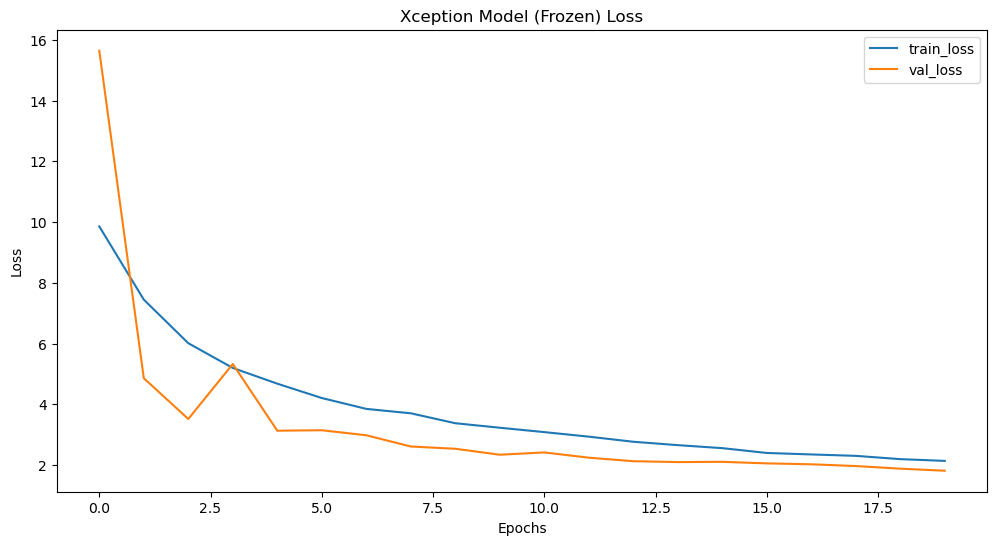

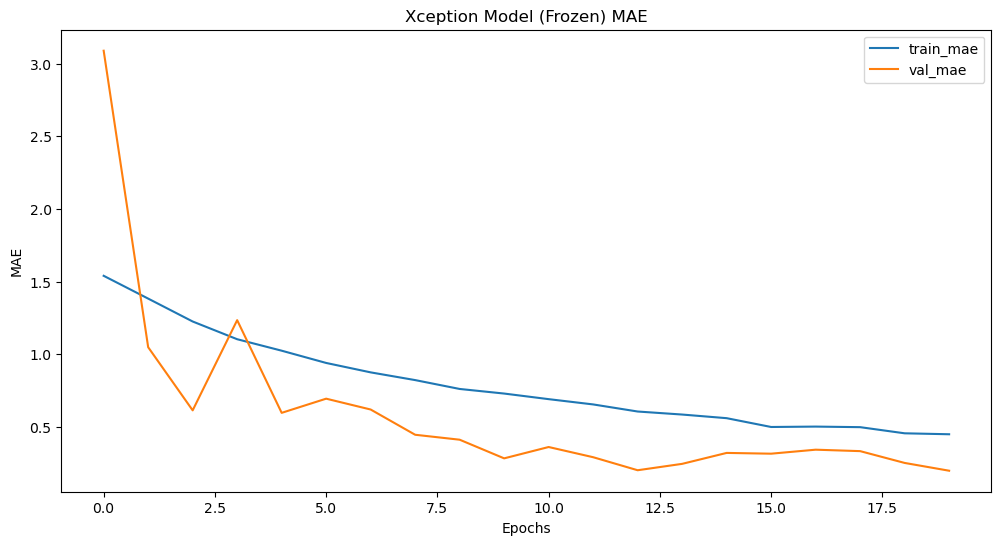

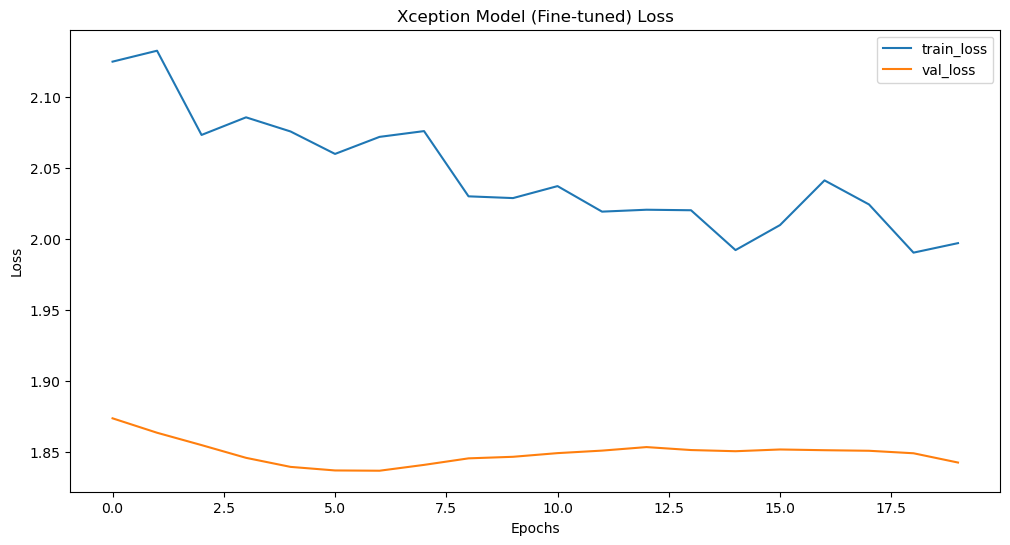

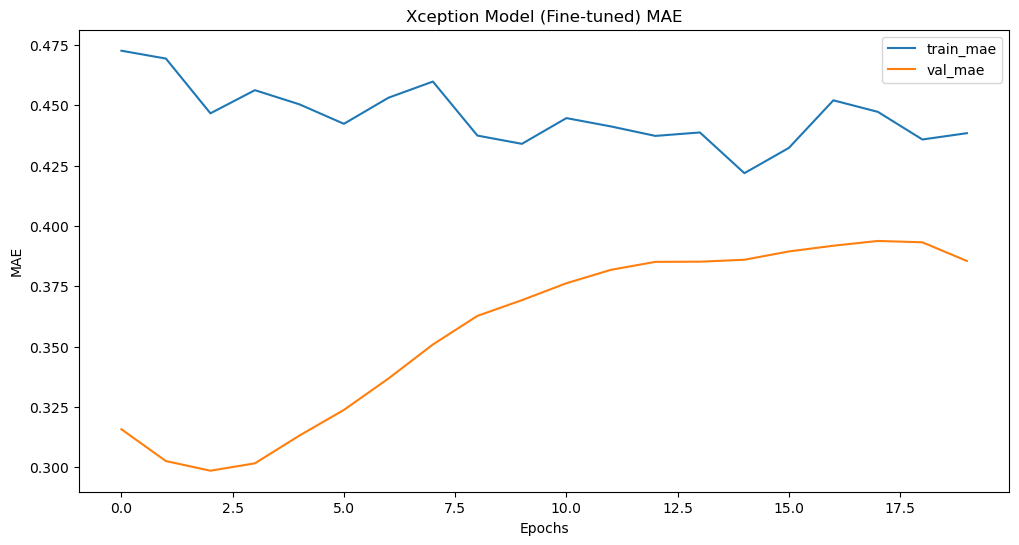

In [11]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['mae'], label='train_mae')
    plt.plot(history.history['val_mae'], label='val_mae')
    plt.title(f'{model_name} MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()
plot_history(history_frozen, 'Xception Model (Frozen)')
plot_history(history_finetune, 'Xception Model (Fine-tuned)')


In [12]:
def euclidean_distance(pred_coords, true_coords):
    # Compute distances for left and right eyes
    dist_left_eye = np.sqrt((pred_coords[:, 0] - true_coords[:, 0])**2 + (pred_coords[:, 1] - true_coords[:, 1])**2)
    dist_right_eye = np.sqrt((pred_coords[:, 2] - true_coords[:, 2])**2 + (pred_coords[:, 3] - true_coords[:, 3])**2)  
    return dist_left_eye, dist_right_eye
def compute_ipd(true_coords):
    ipd = np.sqrt((true_coords[:, 0] - true_coords[:, 2])**2 + (true_coords[:, 1] - true_coords[:, 3])**2)
    return ipd
def calculate_normalized_error(pred_coords, true_coords):
    dist_left_eye, dist_right_eye = euclidean_distance(pred_coords, true_coords)
    ipd = compute_ipd(true_coords)
    normalized_error_left = dist_left_eye / ipd
    normalized_error_right = dist_right_eye / ipd
    return normalized_error_left, normalized_error_right

In [13]:
y_pred_val = model.predict(X_val)
normalized_error_left, normalized_error_right = calculate_normalized_error(y_pred_val, y_val)
mean_normalized_error_left = np.mean(normalized_error_left)
mean_normalized_error_right = np.mean(normalized_error_right)
print(f"Mean Normalized Error (Left Eye) on Validation Set: {mean_normalized_error_left}")
print(f"Mean Normalized Error (Right Eye) on Validation Set: {mean_normalized_error_right}")
overall_mean_normalized_error = (mean_normalized_error_left + mean_normalized_error_right) / 2
print(f"Overall Mean Normalized Error on Validation Set: {overall_mean_normalized_error}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 54s 12s/step
Mean Normalized Error (Left Eye) on Validation Set: 1.357649067688742
Mean Normalized Error (Right Eye) on Validation Set: 2.311013253916208
Overall Mean Normalized Error on Validation Set: 1.834331160802475


In [14]:
y_pred_test = model.predict(X_test)
normalized_error_left_test, normalized_error_right_test = calculate_normalized_error(y_pred_test, y_test)
mean_normalized_error_left_test = np.mean(normalized_error_left_test)
mean_normalized_error_right_test = np.mean(normalized_error_right_test)
print(f"Test Set Mean Normalized Error (Left Eye): {mean_normalized_error_left_test}")
print(f"Test Set Mean Normalized Error (Right Eye): {mean_normalized_error_right_test}")
overall_mean_normalized_error_test = (mean_normalized_error_left_test + mean_normalized_error_right_test) / 2
print(f"Test Set Overall Mean Normalized Error: {overall_mean_normalized_error_test}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 49s 11s/step
Test Set Mean Normalized Error (Left Eye): 1.302064180955115
Test Set Mean Normalized Error (Right Eye): 2.2080712990653355
Test Set Overall Mean Normalized Error: 1.7550677400102253


In [15]:
print(normalized_error_left_test)
print(normalized_error_right_test)

[10.27944857  1.0836601   0.73777889  1.11147529  0.89795194  0.73947097
  0.83695857  1.20668615  1.12210922  0.72597996  0.84546296  0.96683416
  1.15188987  0.97576157  0.94365417  0.94870624  1.01843589  1.10673066
  0.92346424  0.94366888  0.84339306  1.45613797  1.50874925  0.99708392
  1.11093537  0.99341148 14.55469795  1.19552663  1.04498979  1.01308361
  0.7096764   0.92058463  0.684174    0.83210507  1.13370281  1.00101397
  1.04050869  1.12169626  1.19686248  1.03800829  0.94355918  0.9724125
  0.96304395  0.97553379  0.86282532  1.0138144   0.95972333  8.3692695
  0.95741731  0.9017886   1.19174756  0.70684673  1.37168801  1.03271123
  0.67671649  1.15903987  0.68333151  1.03153421  0.64110756  1.49753189
  0.92156882  0.93870461  1.04400108  1.14424096  0.67711691  0.70593106
  0.85258594  1.02230944  1.08048382  1.27556928  1.2176503   1.29556355
  0.88162753  1.24836755  1.02315584  1.33911336  0.89662026  0.94432725
  1.0126687   1.06902549  0.90483636  0.97044081  1.4